In [23]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
  os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your GROQ API key: ")

In [24]:
!pip install langchain-groq


In [25]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,AIMessage

In [26]:
llm=ChatGroq(model="openai/gpt-oss-120b",temperature=0,max_tokens=None,max_retries=3)

In [27]:
def multiply(a:int,b:int)->int:
   """Multiply 2 numbers a & b
   Args:
        a: first input
        b: second input
   """
   return a *b

In [28]:
llm_with_tools = llm.bind_tools([multiply])

In [29]:
toolcall = llm_with_tools.invoke([HumanMessage(content=f" What is the result of this product of 2 numbers: 789 and 456?")])
toolcall

AIMessage(content='', additional_kwargs={'reasoning_content': "We need to compute 789 * 456. Let's calculate.\n\n789 * 456 = 789 * (400 + 50 + 6) = 789*400 + 789*50 + 789*6.\n\n789*400 = 315,600.\n789*50 = 39,450.\n789*6 = 4,734.\n\nSum: 315,600 + 39,450 = 355,050. + 4,734 = 359,784.\n\nCheck with multiplication: 789*456 = ?\n\nAlternatively compute 456*789: 456*700=319,200; 456*80=36,480; 456*9=4,104; sum = 319,200+36,480=355,680; +4,104=359,784. Yes.\n\nThus answer: 359,784.\n\nWe could also use function multiply. Let's do that.", 'tool_calls': [{'id': 'fc_1a8643f5-c476-4c0a-928e-ffc115a91146', 'function': {'arguments': '{"a":789,"b":456}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 224, 'prompt_tokens': 158, 'total_tokens': 382, 'completion_time': 0.470351283, 'completion_tokens_details': {'reasoning_tokens': 191}, 'prompt_time': 0.006432645, 'prompt_tokens_details': None, 'queue_time': 0.16423153, 'total_time': 0.476783928}, 

In [30]:
from langgraph.graph import MessagesState

In [ ]:
class MessagesState(MessagesState):
  pass

In [31]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

In [48]:
def tool_calling_llm(state:MessagesState):
   return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [46]:
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode([multiply]))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")
builder.add_edge("tool_calling_llm",END)
graph = builder.compile()

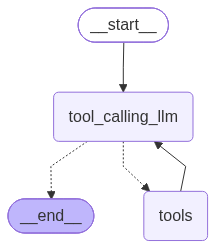

In [47]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
messages = [HumanMessage(content="Give me the product of 678 and 234?")]
messages =graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()


================================ Human Message =================================

Give me the product of 678 and 234?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_a2345fc6-50e3-400f-b925-5afe1c60bc07)
 Call ID: fc_a2345fc6-50e3-400f-b925-5afe1c60bc07
  Args:
    a: 678
    b: 234
================================= Tool Message =================================
Name: multiply

158652
================================== Ai Message ==================================

The product of 678 and 234 is **158,652**.
